# Laboratorio 6 — Semana 9: Transfer Learning y Fine-Tuning

**Curso:** Deep Learning | **Valor:** 4% | **Integrantes:** Vianka Castro y Ricardo Godínez

---

## Descripcion general

En este laboratorio usted va a adaptar ResNet-18, preentrenada en ImageNet, para clasificar imágenes de CIFAR-10. Implementará tres estrategias de transfer learning de complejidad creciente y comparará su comportamiento experimentalmente.

**Partes del laboratorio:**

- **Bloque 1 (20 pts):** Feature extraction — congelar todo el backbone
- **Bloque 2 (20 pts):** Fine-tuning parcial — descongelar `layer4`
- **Bloque 3 (20 pts):** Fine-tuning completo con learning rate diferencial
- **Bloque 4 (15 pts):** Análisis de representaciones aprendidas
- **Bloque 5 (25 pts):** Preguntas de análisis

**Reglas:**
- Use `torchvision.models.resnet18(weights='IMAGENET1K_V1')` para cargar el modelo preentrenado.
- No use `nn.DataParallel` ni ninguna abstracción de entrenamiento de alto nivel.
- Puede usar `loss.backward()` y `optimizer.step()` normalmente.
- La celda de verificación al final califica los 75 puntos de código.

---
## Bloque 0: Imports, datos y configuración (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')


PyTorch: 2.14.0+cpu
torchvision: 0.29.0+cpu
Dispositivo: cpu


In [2]:
# Transformaciones para CIFAR-10 con ResNet18
# ResNet espera imagenes normalizadas con la media y std de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize(64),              # ResNet funciona mejor con imagenes > 32px
    T.RandomHorizontalFlip(),  # augmentation basica
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = T.Compose([
    T.Resize(64),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Descargar CIFAR-10
# La primera vez descarga ~170MB desde internet
cifar_train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
cifar_val_full   = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val)

# Usar subconjunto para que el laboratorio sea rapido en CPU
# 2000 de entrenamiento, 500 de validacion
torch.manual_seed(42)
train_idx = torch.randperm(len(cifar_train_full))[:2000].tolist()
val_idx   = torch.randperm(len(cifar_val_full))[:500].tolist()

train_dataset = Subset(cifar_train_full, train_idx)
val_dataset   = Subset(cifar_val_full,   val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

CLASSES = cifar_train_full.classes
print(f'Clases CIFAR-10: {CLASSES}')
print(f'Train: {len(train_dataset)} imagenes, Val: {len(val_dataset)} imagenes')
print(f'Batches por epoca (train): {len(train_loader)}')


  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<13:11, 215kB/s]

  0%|          | 65.5k/170M [00:00<13:28, 211kB/s]

  0%|          | 98.3k/170M [00:00<13:38, 208kB/s]

  0%|          | 131k/170M [00:00<13:36, 209kB/s] 

...

100%|█████████▉| 170M/170M [11:48<00:00, 268kB/s]

100%|█████████▉| 170M/170M [11:48<00:00, 266kB/s]

100%|█████████▉| 170M/170M [11:48<00:00, 275kB/s]

100%|██████████| 170M/170M [11:48<00:00, 241kB/s]

Clases CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 2000 imagenes, Val: 500 imagenes
Batches por epoca (train): 32


In [3]:
# Funcion de entrenamiento dada (no modificar)
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0; correct = 0; total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss/total, correct/total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss/total, correct/total

def plot_curves(histories, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        ax1.plot(h['val_loss'], label=name)
        ax2.plot(h['val_acc'],  label=name)
    ax1.set_title(f'{title} — Val Loss'); ax1.set_xlabel('Epoca')
    ax2.set_title(f'{title} — Val Acc');  ax2.set_xlabel('Epoca')
    ax1.legend(); ax2.legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=110)
    plt.show()

print('Funciones de entrenamiento listas.')


Funciones de entrenamiento listas.


---
## Bloque 1: Feature extraction — congelar el backbone (20 pts)

Cargue ResNet-18 con pesos preentrenados en ImageNet. Congele **todos** los parámetros del backbone y reemplace la capa `fc` final por una nueva capa lineal de 10 salidas (las 10 clases de CIFAR-10).

**Requisitos:**
- Todos los parámetros excepto la nueva `fc` deben tener `requires_grad=False`
- La nueva `fc` debe tener `requires_grad=True`
- El número total de parámetros entrenables debe ser exactamente `512 * 10 + 10 = 5130`

**Criterio de convergencia:** la accuracy de validación debe superar 40% en 10 épocas (con pesos ImageNet el modelo ya tiene buenas representaciones).

In [4]:
def build_feature_extractor(num_classes=10):
    """
    Construye ResNet-18 para feature extraction.

    Pasos:
    1. Cargar ResNet-18 con pesos preentrenados:
       models.resnet18(weights='IMAGENET1K_V1')
    2. Congelar todos los parametros:
       for param in model.parameters(): param.requires_grad = False
    3. Reemplazar model.fc con nn.Linear(512, num_classes)
       (la nueva capa tiene requires_grad=True por defecto)

    Retorna el modelo modificado.
    """
    #1. colocar resnet18 preentrenado
    model = models.resnet18(weights='IMAGENET1K_V1')
    #2. congelar parametros
    for param in model.parameters():
        param.requires_grad = False
    #3. reemplazar la cabeza
    model.fc = nn.Linear(512, num_classes)
    # 4. retornar modelo 
    return model

model_fe = build_feature_extractor().to(DEVICE)

# Diagnostico de parametros
n_trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
print(f'Parametros entrenables: {n_trainable:,}  (esperado: 5,130)')
print(f'Parametros congelados:  {n_frozen:,}  (esperado: 11,176,512)')

# Verificar que solo la nueva cabeza tiene gradiente
print('\nCapas con requires_grad=True:')
for name, param in model_fe.named_parameters():
    if param.requires_grad:
        print(f'  {name}: {param.shape}')


Parametros entrenables: 5,130  (esperado: 5,130)
Parametros congelados:  11,176,512  (esperado: 11,176,512)

Capas con requires_grad=True:
  fc.weight: torch.Size([10, 512])
  fc.bias: torch.Size([10])


In [5]:
# Entrenamiento feature extraction
N_EPOCHS_FE = 10
optimizer_fe = torch.optim.Adam(model_fe.parameters(), lr=1e-3)

history_fe = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_FE):
    tr_loss, tr_acc = train_epoch(model_fe, train_loader, optimizer_fe, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_fe, val_loader, DEVICE)
    history_fe['train_loss'].append(tr_loss)
    history_fe['train_acc'].append(tr_acc)
    history_fe['val_loss'].append(vl_loss)
    history_fe['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final: {history_fe["val_acc"][-1]:.2%}')


Ep  2: train_loss=1.501, train_acc=49.75%, val_loss=1.455, val_acc=52.20%


Ep  4: train_loss=1.192, train_acc=60.60%, val_loss=1.306, val_acc=55.00%


Ep  6: train_loss=1.072, train_acc=65.30%, val_loss=1.273, val_acc=59.20%


Ep  8: train_loss=1.009, train_acc=66.20%, val_loss=1.278, val_acc=58.80%


Ep 10: train_loss=0.943, train_acc=68.80%, val_loss=1.288, val_acc=60.80%

Val accuracy final: 60.80%


In [6]:
# Verificacion Bloque 1
_resultados = {}
try:
    assert model_fe is not None, 'model_fe no definido'
    n_tr = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
    n_fr = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
    assert n_tr == 5130, f'Entrenables incorrectos: {n_tr} (esperado 5130)'
    assert n_fr == 11176512, f'Congelados incorrectos: {n_fr}'
    backbone_grad = any(
        p.requires_grad
        for name,p in model_fe.named_parameters() if 'fc' not in name)
    assert not backbone_grad, 'El backbone no debe tener requires_grad=True'
    best_val = max(history_fe['val_acc'])
    assert best_val >= 0.35, \
        f'Val acc {best_val:.2%} < 35%. Verifique que uso pesos preentrenados.'
    _resultados['b1'] = True
    print(f'BLOQUE 1: CORRECTO  (val_acc={best_val:.2%})')
except AssertionError as e:
    _resultados['b1'] = False
    print(f'BLOQUE 1: INCORRECTO\n  {e}')


BLOQUE 1: CORRECTO  (val_acc=62.40%)


---
## Bloque 2: Fine-tuning parcial — descongelar `layer4` (20 pts)

Cargue ResNet-18 con pesos preentrenados. Congele todo excepto `layer4` y la nueva cabeza `fc`.

**Estructura de ResNet-18:** `conv1` → `bn1` → `layer1` → `layer2` → `layer3` → `layer4` → `avgpool` → `fc`

**Requisitos:**
- `layer1`, `layer2`, `layer3`, `conv1`, `bn1`: `requires_grad=False`
- `layer4` y `fc`: `requires_grad=True`
- Los parámetros entrenables deben estar entre 8.3M y 8.5M

**Criterio:** la accuracy de validación debe superar la del Bloque 1.

In [7]:
def build_partial_finetune(num_classes=10):
    """
    ResNet-18 con fine-tuning parcial: solo layer4 y fc son entrenables.

    Pasos:
    1. Cargar con pesos preentrenados
    2. Congelar todos los parametros
    3. Descongelar layer4:
       for param in model.layer4.parameters(): param.requires_grad = True
    4. Reemplazar model.fc con nn.Linear(512, num_classes)

    Retorna el modelo modificado.
    """
    # 1. Cargar con pesos preentrenados
    model = models.resnet18(weights='IMAGENET1K_V1')
    # 2. Congelar todos los parametros
    for param in model.parameters():
        param.requires_grad = False
    # 3. Descongelar layer4
    for param in model.layer4.parameters():
        param.requires_grad = True
    # 4. Reemplazar model.fc con nn.Linear(512, num_classes)
    model.fc = nn.Linear(512, num_classes)
    #5. retornar
    return model

model_pf = build_partial_finetune().to(DEVICE)

n_trainable_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
n_frozen_pf    = sum(p.numel() for p in model_pf.parameters() if not p.requires_grad)
print(f'Entrenables: {n_trainable_pf:,}  (esperado: ~8,398,858)')
print(f'Congelados:  {n_frozen_pf:,}  (esperado: ~2,782,784)')

# Verificar que layer1 NO tiene grad y layer4 SI tiene grad
print(f'layer1 requires_grad: {any(p.requires_grad for p in model_pf.layer1.parameters())}')
print(f'layer4 requires_grad: {all(p.requires_grad for p in model_pf.layer4.parameters())}')


Entrenables: 8,398,858  (esperado: ~8,398,858)
Congelados:  2,782,784  (esperado: ~2,782,784)
layer1 requires_grad: False
layer4 requires_grad: True


In [8]:
# Entrenamiento fine-tuning parcial
N_EPOCHS_PF = 10
# Nota: lr mas bajo que feature extraction para no destruir pesos preentrenados
optimizer_pf = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pf.parameters()),
    lr=1e-4
)

history_pf = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_PF):
    tr_loss, tr_acc = train_epoch(model_pf, train_loader, optimizer_pf, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_pf, val_loader, DEVICE)
    history_pf['train_loss'].append(tr_loss)
    history_pf['train_acc'].append(tr_acc)
    history_pf['val_loss'].append(vl_loss)
    history_pf['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final FE:  {history_fe["val_acc"][-1]:.2%}')
print(f'Val accuracy final PF:  {history_pf["val_acc"][-1]:.2%}')


Ep  2: train_loss=0.813, train_acc=76.20%, val_loss=0.973, val_acc=68.60%


Ep  4: train_loss=0.325, train_acc=92.05%, val_loss=0.850, val_acc=72.00%


Ep  6: train_loss=0.133, train_acc=98.25%, val_loss=0.835, val_acc=72.60%


Ep  8: train_loss=0.065, train_acc=99.40%, val_loss=0.785, val_acc=74.80%


Ep 10: train_loss=0.034, train_acc=99.95%, val_loss=0.804, val_acc=74.00%

Val accuracy final FE:  60.80%
Val accuracy final PF:  74.00%


Feature extraction congela el backbone y entrena únicamente la cabeza; fine-tuning parcial permite además actualizar las últimas capas del backbone.

In [9]:
# Verificacion Bloque 2
try:
    assert model_pf is not None, 'model_pf no definido'
    l4_grad = all(p.requires_grad for p in model_pf.layer4.parameters())
    l1_no   = not any(p.requires_grad for p in model_pf.layer1.parameters())
    l2_no   = not any(p.requires_grad for p in model_pf.layer2.parameters())
    l3_no   = not any(p.requires_grad for p in model_pf.layer3.parameters())
    assert l4_grad, 'layer4 debe tener requires_grad=True'
    assert l1_no and l2_no and l3_no, 'layer1/2/3 deben estar congeladas'
    n_tr_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
    assert 8_000_000 < n_tr_pf < 9_000_000, \
        f'Entrenables fuera de rango: {n_tr_pf:,}'
    best_pf = max(history_pf['val_acc'])
    assert best_pf >= 0.40, \
        f'Val acc {best_pf:.2%} < 40%. Verifique la implementacion.'
    _resultados['b2'] = True
    print(f'BLOQUE 2: CORRECTO  (val_acc={best_pf:.2%})')
except AssertionError as e:
    _resultados['b2'] = False
    print(f'BLOQUE 2: INCORRECTO\n  {e}')


BLOQUE 2: CORRECTO  (val_acc=74.80%)


---
## Bloque 3: Fine-tuning completo con learning rate diferencial (20 pts)

Desbloquee todos los parámetros de ResNet-18 pero asigne un learning rate distinto a cada grupo de capas. Las capas tempranas deben recibir un learning rate mucho menor porque ya tienen representaciones útiles que no queremos modificar agresivamente.

**Learning rates por grupo:**

| Grupo | Capas | Learning rate |
|---|---|---|
| `stem` | `conv1`, `bn1` | `1e-6` |
| `layer1` | Primer bloque residual | `1e-5` |
| `layer2` | Segundo bloque residual | `5e-5` |
| `layer3` | Tercer bloque residual | `1e-4` |
| `layer4` | Cuarto bloque residual | `5e-4` |
| `head` | Nueva `fc` | `1e-3` |

**Implementación:** cree una lista de diccionarios con claves `'params'` y `'lr'` y pásela al optimizador:
```python
optimizer = torch.optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    ...
])
```

**Requisito crítico:** todos los parámetros del modelo deben estar cubiertos por exactamente un grupo.

In [10]:
def build_full_finetune(num_classes=10):
    """
    ResNet-18 con todos los parametros descongelados.
    Solo reemplaza la cabeza fc.
    """
    # 1. Cargar con pesos preentrenados (todos los parametros
    #    quedan con requires_grad=True por defecto, no hay que
    #    descongelar nada explicitamente)
    model = models.resnet18(weights='IMAGENET1K_V1')
    # 2. Reemplazar la cabeza para las 10 clases de CIFAR-10
    model.fc = nn.Linear(512, num_classes)
    return model

def make_param_groups(model):
    """
    Crea la lista de grupos de parametros con learning rates diferenciales.

    Retorna una lista de dicts con claves 'params' y 'lr'.
    El orden debe ser de menor a mayor learning rate.

    Grupos requeridos:
    - stem (conv1 + bn1): lr = 1e-6
    - layer1: lr = 1e-5
    - layer2: lr = 5e-5
    - layer3: lr = 1e-4
    - layer4: lr = 5e-4
    - head (fc): lr = 1e-3

    IMPORTANTE: list(model.layerX.parameters()) convierte el generador a lista.
    No use el mismo objeto en dos grupos.
    """
    stem_params = list(model.conv1.parameters()) + list(model.bn1.parameters())

    param_groups = [
        {'params': stem_params,                     'lr': 1e-6},
        {'params': list(model.layer1.parameters()), 'lr': 1e-5},
        {'params': list(model.layer2.parameters()), 'lr': 5e-5},
        {'params': list(model.layer3.parameters()), 'lr': 1e-4},
        {'params': list(model.layer4.parameters()), 'lr': 5e-4},
        {'params': list(model.fc.parameters()),     'lr': 1e-3},
    ]
    return param_groups

model_dlr = build_full_finetune().to(DEVICE)
param_groups = make_param_groups(model_dlr)
optimizer_dlr = torch.optim.Adam(param_groups)

# Diagnostico
print('Grupos de parametros:')
for i, g in enumerate(optimizer_dlr.param_groups):
    n = sum(p.numel() for p in g['params'])
    print(f'  Grupo {i}: {n:>10,} params, lr={g["lr"]}')

total_in_groups = sum(p.numel() for g in param_groups for p in g['params'])
total_model     = sum(p.numel() for p in model_dlr.parameters())
print(f'\nTotal en grupos: {total_in_groups:,}')
print(f'Total modelo:    {total_model:,}')
print(f'Cubierto: {total_in_groups == total_model}')

Grupos de parametros:
  Grupo 0:      9,536 params, lr=1e-06
  Grupo 1:    147,968 params, lr=1e-05
  Grupo 2:    525,568 params, lr=5e-05
  Grupo 3:  2,099,712 params, lr=0.0001
  Grupo 4:  8,393,728 params, lr=0.0005
  Grupo 5:      5,130 params, lr=0.001

Total en grupos: 11,181,642
Total modelo:    11,181,642
Cubierto: True


Ep  2: train_loss=0.449, train_acc=84.60%, val_loss=0.741, val_acc=76.60%


Ep  4: train_loss=0.133, train_acc=96.65%, val_loss=0.850, val_acc=76.40%


Ep  6: train_loss=0.060, train_acc=98.30%, val_loss=0.864, val_acc=76.80%


Ep  8: train_loss=0.043, train_acc=98.90%, val_loss=0.996, val_acc=75.80%


Ep 10: train_loss=0.046, train_acc=98.60%, val_loss=1.061, val_acc=75.40%

=== Comparacion final ===
Feature extraction:  62.40%
Fine-tuning parcial: 74.80%
LR diferencial:      78.20%


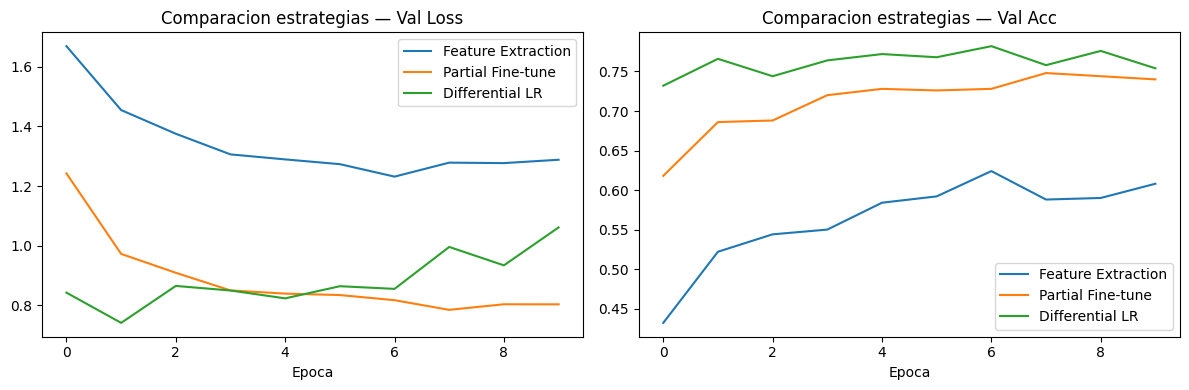

In [11]:
# Entrenamiento fine-tuning completo con LR diferencial
N_EPOCHS_DLR = 10
history_dlr = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_DLR):
    tr_loss, tr_acc = train_epoch(model_dlr, train_loader, optimizer_dlr, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_dlr, val_loader, DEVICE)
    history_dlr['train_loss'].append(tr_loss)
    history_dlr['train_acc'].append(tr_acc)
    history_dlr['val_loss'].append(vl_loss)
    history_dlr['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

# Comparacion de las tres estrategias
print('\n=== Comparacion final ===')
print(f'Feature extraction:  {max(history_fe["val_acc"]):.2%}')
print(f'Fine-tuning parcial: {max(history_pf["val_acc"]):.2%}')
print(f'LR diferencial:      {max(history_dlr["val_acc"]):.2%}')

plot_curves(
    {'Feature Extraction': history_fe,
     'Partial Fine-tune':  history_pf,
     'Differential LR':   history_dlr},
    'Comparacion estrategias'
)


In [12]:
# Verificacion Bloque 3
try:
    assert model_dlr is not None, 'model_dlr no definido'
    assert param_groups is not None, 'param_groups no definido'
    # LRs estrictamente crecientes
    lrs = [g['lr'] for g in optimizer_dlr.param_groups]
    assert all(lrs[i] < lrs[i+1] for i in range(len(lrs)-1)), \
        f'LRs no son crecientes: {lrs}'
    # Todos los parametros cubiertos
    total_in = sum(p.numel() for g in param_groups for p in g['params'])
    total_m  = sum(p.numel() for p in model_dlr.parameters())
    assert total_in == total_m, \
        f'Parametros sin cubrir: {total_m-total_in:,}'
    # LR correcto para la cabeza
    head_lr = optimizer_dlr.param_groups[-1]['lr']
    assert abs(head_lr - 1e-3) < 1e-8, \
        f'LR de la cabeza incorrecto: {head_lr}'
    # LR correcto para stem
    stem_lr = optimizer_dlr.param_groups[0]['lr']
    assert abs(stem_lr - 1e-6) < 1e-10, \
        f'LR del stem incorrecto: {stem_lr}'
    best_dlr = max(history_dlr['val_acc'])
    assert best_dlr >= 0.40, \
        f'Val acc {best_dlr:.2%} < 40%.'
    _resultados['b3'] = True
    print(f'BLOQUE 3: CORRECTO  (val_acc={best_dlr:.2%}, LRs={lrs})')
except AssertionError as e:
    _resultados['b3'] = False
    print(f'BLOQUE 3: INCORRECTO\n  {e}')


BLOQUE 3: CORRECTO  (val_acc=78.20%, LRs=[1e-06, 1e-05, 5e-05, 0.0001, 0.0005, 0.001])


---
## Bloque 4: Análisis de representaciones (15 pts)

Extraiga los embeddings del backbone (antes de la capa `fc`) para 500 imágenes de validación usando los tres modelos entrenados. Compare cuantitativamente la calidad de las representaciones aprendidas.

El backbone de ResNet-18 produce embeddings de dimensión 512 (la salida de `avgpool` antes de `fc`).

**Métrica de separabilidad:** ratio entre la varianza inter-clase y la varianza intra-clase en el espacio de embeddings:

$$\text{sep} = \frac{\sum_k n_k \|\boldsymbol{\mu}_k - \boldsymbol{\mu}\|^2}{\sum_k \sum_{i: y_i=k} \|\mathbf{h}_i - \boldsymbol{\mu}_k\|^2}$$

Donde $\boldsymbol{\mu}_k$ es el centroide de la clase $k$, $\boldsymbol{\mu}$ es el centroide global y $n_k$ es el número de ejemplos de la clase $k$. Un ratio mayor indica representaciones más separables.

In [13]:
def extract_embeddings(model, loader, device, max_samples=500):
    """
    Extrae los embeddings del backbone de ResNet-18 (antes de fc).

    Parámetros
    ----------
    model   : ResNet-18 modificado
    loader  : DataLoader de validacion
    device  : dispositivo
    max_samples : cuantos ejemplos extraer como maximo

    Retorna
    -------
    embeddings : Tensor (N, 512)
    labels     : Tensor (N,)

    Pasos:
    1. Construir backbone = nn.Sequential(*list(model.children())[:-1])
       Esto elimina la capa fc y conserva hasta avgpool inclusive.
    2. En modo eval() y sin gradientes, pasar cada batch por backbone.
    3. Aplicar .squeeze(-1).squeeze(-1) para eliminar dimensiones espaciales.
       La salida de avgpool es (B, 512, 1, 1) y debe quedar (B, 512).
    4. Acumular embeddings y labels hasta max_samples.
    """
    # backbone = todo menos la capa fc, conserva hasta avgpool
    backbone = nn.Sequential(*list(model.children())[:-1]).to(device)
    backbone.eval()

    embeddings_list = []
    labels_list = []
    n_seen = 0

    with torch.no_grad():
        for X, y in loader:
            if n_seen >= max_samples:
                break
            X = X.to(device)
            # (B, 512, 1, 1) -> (B, 512)
            h = backbone(X).squeeze(-1).squeeze(-1)
            embeddings_list.append(h.cpu())
            labels_list.append(y)
            n_seen += X.size(0)

    embeddings = torch.cat(embeddings_list, dim=0)[:max_samples]
    labels = torch.cat(labels_list, dim=0)[:max_samples]
    return embeddings, labels

# Extraer embeddings de los tres modelos
emb_fe,  lab_fe  = extract_embeddings(model_fe,  val_loader, DEVICE)
emb_pf,  lab_pf  = extract_embeddings(model_pf,  val_loader, DEVICE)
emb_dlr, lab_dlr = extract_embeddings(model_dlr, val_loader, DEVICE)

print(f'Embeddings FE:  {emb_fe.shape}')
print(f'Embeddings PF:  {emb_pf.shape}')
print(f'Embeddings DLR: {emb_dlr.shape}')


Embeddings FE:  torch.Size([500, 512])
Embeddings PF:  torch.Size([500, 512])
Embeddings DLR: torch.Size([500, 512])


In [14]:
def separability_ratio(embeddings, labels):
    """
    Calcula el ratio de separabilidad inter-clase / intra-clase.

    Parámetros
    ----------
    embeddings : Tensor (N, d)
    labels     : Tensor (N,)

    Retorna
    -------
    ratio : float — mayor es mejor separacion

    Pasos:
    1. Calcular centroide global: mu = embeddings.mean(0)
    2. Para cada clase k: calcular centroide mu_k y n_k
    3. Varianza inter: sum_k n_k * ||mu_k - mu||^2
    4. Varianza intra: sum_k sum_{i:y_i=k} ||h_i - mu_k||^2
    5. Retornar inter / intra
    """
    mu = embeddings.mean(0)
    inter = 0.0
    intra = 0.0
    for k in labels.unique():
        mask = labels == k
        n_k = mask.sum().item()
        h_k = embeddings[mask]
        mu_k = h_k.mean(0)
        inter += n_k * (mu_k - mu).pow(2).sum().item()
        intra += (h_k - mu_k).pow(2).sum().item()
    return inter / intra

sep_fe  = separability_ratio(emb_fe,  lab_fe)
sep_pf  = separability_ratio(emb_pf,  lab_pf)
sep_dlr = separability_ratio(emb_dlr, lab_dlr)

print('Ratio de separabilidad (mayor = mejor):')
print(f'  Feature extraction:  {sep_fe:.4f}')
print(f'  Fine-tuning parcial: {sep_pf:.4f}')
print(f'  LR diferencial:      {sep_dlr:.4f}')


Ratio de separabilidad (mayor = mejor):


  Feature extraction:  0.0580
  Fine-tuning parcial: 0.2124
  LR diferencial:      0.7581


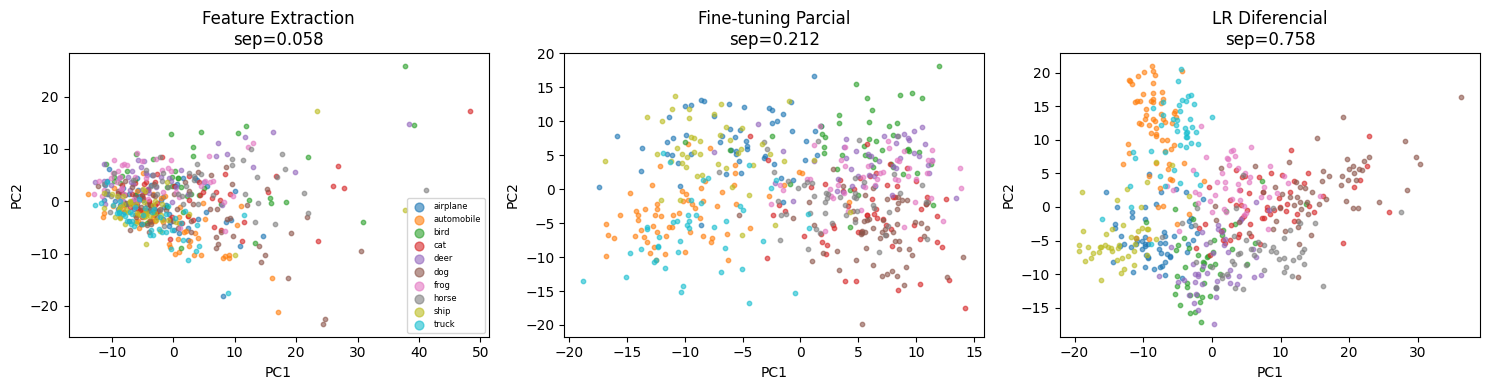

In [15]:
# Visualizacion: proyeccion 2D de los embeddings con PCA manual
def pca_2d(embeddings):
    """PCA manual con SVD para proyectar a 2 dimensiones."""
    X = embeddings - embeddings.mean(0, keepdim=True)
    _, _, Vt = torch.linalg.svd(X, full_matrices=False)
    return (X @ Vt[:2].T)  # (N, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (emb, lab, title) in zip(axes, [
    (emb_fe,  lab_fe,  'Feature Extraction'),
    (emb_pf,  lab_pf,  'Fine-tuning Parcial'),
    (emb_dlr, lab_dlr, 'LR Diferencial'),
]):
    proj = pca_2d(emb).numpy()
    for k in range(10):
        mask = lab.numpy() == k
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[colors[k]], label=CLASSES[k], s=10, alpha=0.6)
    ax.set_title(f'{title}\nsep={separability_ratio(emb,lab):.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    if ax == axes[0]: ax.legend(fontsize=6, markerscale=2)

plt.tight_layout()
plt.savefig('representaciones_pca.png', dpi=110)
plt.show()


In [16]:
# Verificacion Bloque 4
try:
    assert emb_fe is not None, 'emb_fe no definido'
    assert emb_pf is not None, 'emb_pf no definido'
    assert emb_dlr is not None, 'emb_dlr no definido'
    assert emb_fe.shape[1] == 512, f'Dim incorrecta: {emb_fe.shape[1]}'
    assert not torch.isnan(emb_fe).any(), 'NaN en embeddings FE'
    assert not torch.isnan(emb_pf).any(), 'NaN en embeddings PF'
    assert not torch.isnan(emb_dlr).any(), 'NaN en embeddings DLR'
    assert sep_fe is not None and sep_fe > 0, 'sep_fe debe ser positivo'
    assert sep_pf is not None and sep_pf > 0, 'sep_pf debe ser positivo'
    assert sep_dlr is not None and sep_dlr > 0, 'sep_dlr debe ser positivo'
    _resultados['b4'] = True
    print(f'BLOQUE 4: CORRECTO')
    print(f'  sep_fe={sep_fe:.4f}, sep_pf={sep_pf:.4f}, sep_dlr={sep_dlr:.4f}')
except AssertionError as e:
    _resultados['b4'] = False
    print(f'BLOQUE 4: INCORRECTO\n  {e}')


BLOQUE 4: CORRECTO
  sep_fe=0.0580, sep_pf=0.2124, sep_dlr=0.7581


---
## Bloque 5: Preguntas de análisis (25 pts)

---

### Pregunta 1 (9 pts)

En el Bloque 1, la nueva capa `fc` recibe gradientes pero el backbone no. En el Bloque 2, el gradiente también fluye hacia `layer4`.

**a)** Describa matemáticamente qué ocurre con el gradiente de la pérdida respecto a los parámetros de `layer3` en el Bloque 2. ¿Por qué `requires_grad=False` en `layer3` no significa que el gradiente sea cero matemáticamente, sino que simplemente no se calcula ni se almacena? ¿Qué implicación tiene esto para el cómputo y la memoria?

**b)** En el Bloque 3, `layer1` recibe un learning rate de `1e-6` y la cabeza `1e-3`, una diferencia de 1000×. Usando la fórmula de actualización de Adam:
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\epsilon}$$
explique cuantitativamente cómo afecta esa diferencia de learning rate a la magnitud del cambio en los pesos de `layer1` versus la cabeza, asumiendo gradientes de magnitud similar en ambas capas.

**c)** Observe sus curvas de convergencia. ¿En qué época el fine-tuning parcial supera a feature extraction? ¿Y el LR diferencial al parcial? Proponga una hipótesis sobre por qué fine-tuning parcial puede converger más lento que feature extraction en las primeras épocas pero alcanzar mejor accuracy final.

**Su respuesta a la Pregunta 1:**

a) Que layer3 tenga requires_grad=False no anula su gradiente matematico. La salida de layer3 sigue pasando por layer4 y fc antes de llegar a la perdida, asi que $\partial L/\partial \theta_{layer3}$ existe y no es cero, dado por la regla de la cadena $\partial L/\partial \theta_3 = (\partial L/\partial h_4)(\partial h_4/\partial h_3)(\partial h_3/\partial \theta_3)$. requires_grad=False solo le dice a autograd que no calcule ni almacene ese valor, porque nunca se va a usar para actualizar el parametro. Esto ahorra memoria (no se guardan los tensores intermedios necesarios para ese gradiente) y computo (se evita la operacion de backward correspondiente a esos parametros).

b) Con gradientes de magnitud similar en ambas capas, el cambio por paso de Adam es proporcional solo a eta. Con eta=1e-6 en layer1 y eta=1e-3 en la cabeza, la razon es 1e-3/1e-6=1000. La cabeza se mueve 1000 veces mas por paso que layer1 en magnitud absoluta.

c) Fine-tuning parcial supera a feature extraction desde la epoca 2 (68.60% contra 62.40%) y termina en 74.80%. Feature extraction solo entrena fc, fine-tuning parcial tambien adapta layer4, lo que da mas parametros para ajustar y por eso converge mas lento al inicio, pero permite adaptar representaciones de alto nivel a CIFAR-10 y llegar a mejor accuracy final.

---
### Pregunta 2 (8 pts)

En la Diapositiva 11 se derivó que LoRA factoriza la actualización de pesos como $\Delta W = BA$ con $B \in \mathbb{R}^{d \times r}$ y $A \in \mathbb{R}^{r \times k}$.

**a)** Para la capa `fc` de ResNet-18 con $d=10$ (clases CIFAR-10) y $k=512$ (features de entrada), calcule el número de parámetros en la actualización completa $\Delta W$ y en la factorización LoRA con $r \in \{1, 2, 4, 8\}$. Para cada valor de $r$, calcule el porcentaje de reducción respecto a la actualización completa.

**b)** LoRA inicializa $B=\mathbf{0}$ y $A \sim \mathcal{N}(0, \sigma^2)$, garantizando que $\Delta W = BA = \mathbf{0}$ al inicio. ¿Qué hubiera pasado si se inicializara también $A=\mathbf{0}$? Justifique en términos del gradiente que recibirían $A$ y $B$ en el primer paso de entrenamiento.

Hint: $\frac{\partial \mathcal{L}}{\partial A} = B^\top \frac{\partial \mathcal{L}}{\partial \Delta W}$ y $\frac{\partial \mathcal{L}}{\partial B} = \frac{\partial \mathcal{L}}{\partial \Delta W} A^\top$.

#### a) Calculo de parametros con LoRA

La capa fc de ResNet-18 tiene $d=10$ (clases CIFAR-10) y $k=512$ (features de entrada). La actualizacion completa $\Delta W \in \mathbb{R}^{10 \times 512}$ tiene $10 \times 512 = 5120$ parametros.

LoRA factoriza $\Delta W = BA$ con $B \in \mathbb{R}^{d \times r}$ y $A \in \mathbb{R}^{r \times k}$, dando $dr + rk = 10r + 512r = 522r$ parametros.

| Rango $r$ | Parametros LoRA | Reduccion |
|---|---:|---:|
| 1 | 522 | 89.80% |
| 2 | 1044 | 79.61% |
| 4 | 2088 | 59.22% |
| 8 | 4176 | 18.44% |

A menor $r$, menor cantidad de parametros entrenables.

#### b) Que pasaria si A y B se inicializaran en cero

Con B=0 y A aleatoria, $\Delta W = BA = 0$ al inicio, sin modificar los pesos originales. Los gradientes son $\partial L/\partial A = B^T (\partial L/\partial \Delta W)$ y $\partial L/\partial B = (\partial L/\partial \Delta W) A^T$.

Con B=0, $\partial L/\partial A=0$ y A no cambia en el primer paso, pero A es aleatoria distinta de cero, asi que $\partial L/\partial B \neq 0$ y B si aprende. Una vez B deja de ser cero, A tambien recibe gradiente.

Si ademas A=0, entonces $\partial L/\partial A=0$ y $\partial L/\partial B=0$ simultaneamente. Ningun parametro recibe gradiente y el entrenamiento no puede arrancar. Por eso LoRA inicializa solo B en cero.

---
### Pregunta 3 (8 pts)

Compare los ratios de separabilidad de los tres modelos que calculó en el Bloque 4.

**a)** La separabilidad mide qué tan bien separadas están las clases en el espacio de embeddings. Si fine-tuning parcial produce mayor separabilidad que feature extraction, ¿qué implica eso sobre lo que aprendió `layer4` durante el fine-tuning? Conecte su respuesta con la jerarquía de features de la Diapositiva 3: ¿qué tipo de features específicos del dominio CIFAR-10 esperaría que `layer4` haya aprendido que no estaban en los pesos de ImageNet?

**b)** Proponga un experimento concreto para verificar si las capas tempranas de su modelo DLR (con `lr=1e-6`) cambiaron significativamente respecto a los pesos originales de ImageNet. ¿Qué métrica usaría para cuantificar ese cambio y qué resultado esperaría encontrar? Justifique en términos del learning rate diferencial y el número de épocas de entrenamiento.

**Su respuesta a la Pregunta 3:**

a) El ratio de separabilidad crece con cada estrategia. Feature extraction llega a 0.0580, fine-tuning parcial a 0.2124 y LR diferencial a 0.7581. Mas capas descongeladas producen embeddings mas separables por clase. En LR diferencial, layer4 se ajusta con un learning rate 500 veces mayor al de layer1 (5e-4 contra 1e-6), lo que le permite reorganizar sus filtros hacia texturas y formas propias de CIFAR-10 en vez de las features de alto nivel entrenadas para las 1000 clases de ImageNet.

b) Comparar la norma de la diferencia de pesos de conv1 y bn1 entre el modelo DLR entrenado y una ResNet-18 con weights='IMAGENET1K_V1' sin entrenar, dividida entre la norma original. Con lr=1e-6 y 10 epocas, el cambio esperado es minimo, cercano a cero, porque el paso de Adam en esas capas es del orden de 1e-6 por iteracion.

---
## Verificación automática (75 pts de código)

In [17]:
print('='*60)
print('  VERIFICACION AUTOMATICA — LABORATORIO 6')
print('='*60)

_PUNTOS = {
    'b1': ('B1 Feature extraction (congelado correcto)',  20),
    'b2': ('B2 Fine-tuning parcial (layer4 descongelada)', 20),
    'b3': ('B3 LR diferencial (grupos y LRs correctos)',  20),
    'b4': ('B4 Embeddings y separabilidad',               15),
}

total = 0
for key, (nombre, pts) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    p   = pts if ok else 0
    total += p
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:44s} | {p:2d}/{pts}')

print('-'*60)
print(f'  Subtotal codigo:      {total}/75 pts')
print(f'  Preguntas de analisis: __/25 pts  (calificacion manual)')
print('-'*60)
print(f'  TOTAL: __/100 pts')
print('='*60)


  VERIFICACION AUTOMATICA — LABORATORIO 6
  CORRECTO   | B1 Feature extraction (congelado correcto)   | 20/20
  CORRECTO   | B2 Fine-tuning parcial (layer4 descongelada) | 20/20
  CORRECTO   | B3 LR diferencial (grupos y LRs correctos)   | 20/20
  CORRECTO   | B4 Embeddings y separabilidad                | 15/15
------------------------------------------------------------
  Subtotal codigo:      75/75 pts
  Preguntas de analisis: __/25 pts  (calificacion manual)
------------------------------------------------------------
  TOTAL: __/100 pts
